# Word Embedding

Word Embedding is an approach for representing words (and sometimes documents) as dense numeric vectors in a lower-dimensional space.

The main idea is that words with similar meanings should have similar vector representations. This helps machine learning models understand semantic relationships between words better than one-hot or sparse count-based representations.

## Popular Word2Vec Architectures

Two of the most popular Word2Vec training architectures are:

- **CBOW (Continuous Bag of Words):** predicts the current/target word from surrounding context words.
- **Skip-gram:** predicts surrounding context words from the current/target word.

In practice:

- Skip-gram often produces higher-quality embeddings, especially for rare words.
- CBOW is usually faster to train.

## Example Corpus

We can start from a tiny tokenized corpus like this:

```python
sentences = [
    ['I', 'love', 'nlp'],
    ['I', 'will', 'learn', 'nlp', 'in', '2', 'months'],
    ['nlp', 'is', 'future'],
    ['nlp', 'saves', 'time', 'and', 'solves', 'lot', 'of', 'industry', 'problems'],
    ['nlp', 'uses', 'machine', 'learning']
]
```

## What Is Gensim?

**Gensim** is a Python library for unsupervised topic modeling and vector-space modeling.

For this lecture, we use it because it provides a clean and widely used implementation of Word2Vec (CBOW and Skip-gram).

In [2]:
!pip install --no-cache-dir gensim

In [3]:
!pip show gensim

Name: gensim
Version: 4.4.0
Summary: Python framework for fast Vector Space Modelling
Home-page: https://radimrehurek.com/gensim/
Author: Radim Rehurek
Author-email: me@radimrehurek.com
License: LGPL-2.1-only
Location: C:\Users\NewTech\anaconda3\envs\nlp_course_2026\Lib\site-packages
Requires: numpy, scipy, smart_open
Required-by: 


## Skip-gram Example (Word2Vec with `sg=1`)

In [4]:
import gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

# Sample training data: list of tokenized sentences
sentences = [
    ["machine", "learning", "is", "fun"],
    ["nlp", "is", "a", "part", "of", "ai"],
    ["word2vec", "is", "used", "in", "nlp"],
    ["ai", "and", "ml", "are", "related"]
]

# Train a skip-gram Word2Vec model
# vector_size: size of word embeddings (50-dimensional vectors)
# window: context window size (3 words to the left and right)
# min_count: ignore words with total frequency lower than this
# sg=1: use skip-gram architecture (sg=0 would use CBOW)
skipgram = Word2Vec(sentences=sentences, vector_size=50, window=3, min_count=1, sg=1)

# Print a summary of the trained model
print(skipgram)
print()

# Access the vector for a specific word using .wv (word vectors)
print("Vector for 'nlp':")
print(skipgram.wv['nlp'])  # Correct in Gensim 4+

Word2Vec<vocab=16, vector_size=50, alpha=0.025>

Vector for 'nlp':
[-0.01724299  0.00733506  0.01038127  0.01148213  0.01492983 -0.01233896
  0.00221257  0.01209787 -0.005682   -0.01235447 -0.00081482 -0.01673872
 -0.01119731  0.01420705  0.00670651  0.01444848  0.01360469  0.01506143
 -0.00758605 -0.00112417  0.00469611 -0.00903708  0.01678387 -0.01971075
  0.01352608  0.0058306  -0.00986289  0.00879936 -0.0034799   0.01342455
  0.01993109 -0.00873157 -0.00120177 -0.01139666  0.00770159  0.00557531
  0.01378737  0.01220216  0.01907486  0.01854802  0.01579738 -0.01397667
 -0.01831276 -0.00071363 -0.00619568  0.01578892  0.01187841 -0.00308866
  0.00302302  0.0035785 ]


In [5]:
# Expected error demo: 'deep' does not exist in the tiny training corpus
try:
    print(skipgram.wv['deep'])
except KeyError as e:
    print("Expected KeyError:", e)

Expected KeyError: "Key 'deep' not present"


['is', 'ai', 'nlp', 'related', 'are', 'ml', 'and', 'in', 'used', 'word2vec', 'of', 'part', 'a', 'fun', 'learning', 'machine']



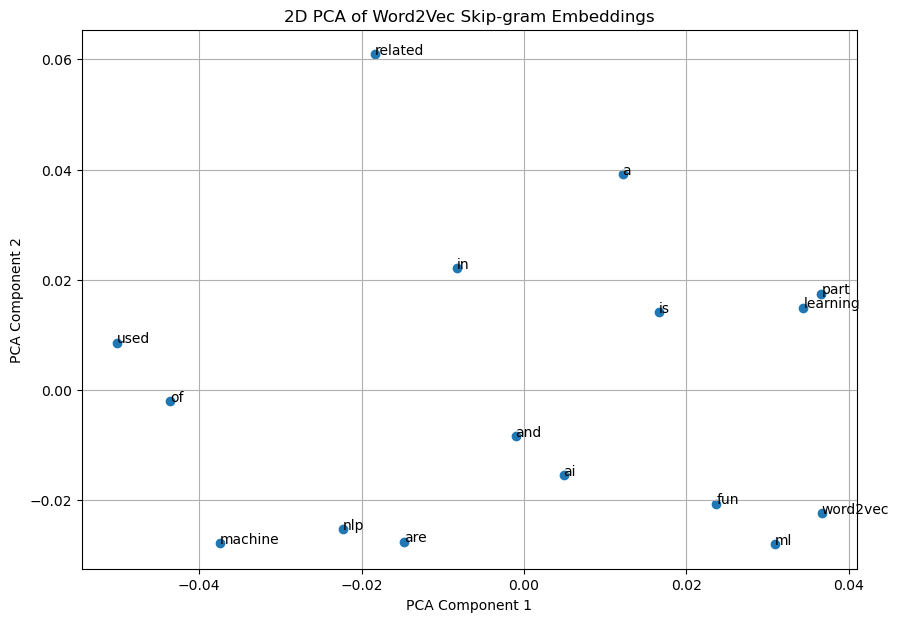

In [6]:
# Save model
skipgram.save('skipgram.bin')

# Load model
skipgram = Word2Vec.load('skipgram.bin')

# Matrix of learned word vectors
X = skipgram.wv.vectors

# Reduce word vectors to 2D using PCA for visualization
pca = PCA(n_components=2)
result = pca.fit_transform(X)

# Create a scatter plot of the projection
plt.figure(figsize=(10, 7))
plt.scatter(result[:, 0], result[:, 1])

# Get list of words corresponding to the vectors
words = skipgram.wv.index_to_key  # Replaces .vocab in Gensim 4.x
print(words)
print()

# Annotate each point with the corresponding word
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("2D PCA of Word2Vec Skip-gram Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

## CBOW Example (Word2Vec with `sg=0`)

In [7]:
import gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

# Sample training data: list of tokenized sentences
sentences = [
    ["machine", "learning", "is", "fun"],
    ["nlp", "is", "a", "part", "of", "ai"],
    ["word2vec", "is", "used", "in", "nlp"],
    ["ai", "and", "ml", "are", "related"]
]

# Train a CBOW Word2Vec model (sg=0)
cbow = Word2Vec(sentences=sentences, vector_size=50, min_count=1, sg=0)

# Print a summary of the trained model
print(cbow)
print()

# Access the vector for a specific word using .wv (word vectors)
print("Vector for 'nlp':")
print(cbow.wv['nlp'])

Word2Vec<vocab=16, vector_size=50, alpha=0.025>

Vector for 'nlp':
[-0.01724413  0.00733218  0.01038146  0.01148653  0.01493333 -0.01233861
  0.00221467  0.01208969 -0.00568723 -0.01234805 -0.00081589 -0.01674051
 -0.0111995   0.01420603  0.00670273  0.0144555   0.0136057   0.01506174
 -0.00758473 -0.00112034  0.00469724 -0.00903278  0.01678457 -0.01971817
  0.01352866  0.00583459 -0.00985886  0.00879602 -0.00347931  0.01342133
  0.01993446 -0.00873209 -0.00120214 -0.01139479  0.00770086  0.00557371
  0.01378044  0.0121971   0.01907763  0.01855318  0.01580062 -0.01397482
 -0.01830948 -0.00071335 -0.00619475  0.01579382  0.01187387 -0.00309138
  0.00302541  0.00358002]


## fastText: Subword-Aware Word Embeddings



fastText is an embedding algorithm (from Meta AI) that extends Word2Vec by representing each word as a bag of character n-grams.



### Why fastText?



Word2Vec learns one vector per full word token. This can be limiting when:



- a word is rare

- a word is misspelled

- a word was never seen during training (out-of-vocabulary, OOV)



fastText helps by composing a word vector from subword pieces (character n-grams), which usually improves robustness for morphology-rich languages and noisy text.



### Word2Vec vs fastText (main differences)



- **Word2Vec:** one vector per word token

- **fastText:** vector built from character n-grams + word information

- **OOV handling:** Word2Vec cannot infer unseen words, while fastText can often produce reasonable vectors from subwords



This is why fastText is often preferred when your corpus is small or contains many rare/variant words.


In [1]:
from gensim.models import FastText



# Reuse the same tokenized training data

sentences = [

    ["machine", "learning", "is", "fun"],

    ["nlp", "is", "a", "part", "of", "ai"],

    ["word2vec", "is", "used", "in", "nlp"],

    ["ai", "and", "ml", "are", "related"]

]



# Train fastText

# vector_size: embedding size

# window: context size

# min_count: minimum token frequency

# sg=1: skip-gram style training objective

# min_n/max_n: character n-gram range used for subwords

fasttext_model = FastText(

    sentences=sentences,

    vector_size=50,

    window=3,

    min_count=1,

    sg=1,

    min_n=3,

    max_n=6

)



print(fasttext_model)

print()



print("Vector for 'nlp' (fastText):")

print(fasttext_model.wv["nlp"])

print()



# OOV example: token not seen exactly during training

# fastText can still infer a vector from character n-grams

oov_word = "nlpp"

print(f"Vector for OOV-like token '{oov_word}' (fastText):")

print(fasttext_model.wv[oov_word])

print()



print("Most similar words to 'nlp' (fastText):")

print(fasttext_model.wv.most_similar("nlp", topn=5))


FastText<vocab=16, vector_size=50, alpha=0.025>

Vector for 'nlp' (fastText):
[-3.9995793e-04  3.0331186e-03  1.7177983e-03 -3.0937311e-03
  4.4779754e-03 -1.3043649e-03  5.4037012e-03  1.2615398e-03
 -1.9597023e-06 -6.9286288e-03  2.2751477e-03  6.9002300e-03
 -2.5610526e-03  8.0673965e-03 -1.0695448e-03  4.8457296e-03
  9.4329141e-04  2.1290269e-03 -3.7438942e-03 -2.3974371e-03
  1.3690785e-03 -3.9841342e-03 -3.9728852e-03 -3.2163539e-03
 -6.5949447e-03 -5.1122153e-04 -1.7189567e-03  6.9565035e-04
  4.2879460e-03 -2.6043481e-03  8.9619160e-03 -5.6150490e-03
  1.9621660e-03 -7.7676997e-03 -6.5236422e-03  2.9900917e-03
 -5.5608223e-03 -1.9502834e-03  1.8180069e-03 -9.6217159e-04
  5.1117241e-03  3.0246763e-03 -6.3066878e-03 -4.7339327e-04
 -1.9855925e-03  6.4946580e-05  2.1135504e-03  9.2453574e-04
  1.2270574e-03  3.8726587e-04]

Vector for OOV-like token 'nlpp' (fastText):
[-9.2591357e-04  2.4279177e-03  1.3771304e-05 -3.0095358e-03
 -2.3752195e-03 -1.1394836e-03 -1.4759644e-03  5.51